# Multi-Scale Optimization: Demo Notebook

**Author:** Ivan Pacenti (21414814)
**Course:** MAIE5532 — Machine Learning System
**Assignment:** Programming Assignment 2

This notebook demonstrates the key results of the multi-scale optimization
pipeline developed in Parts 1–4. It loads the pre-computed metrics from each
part and visualizes them side-by-side.

In [3]:
# Setup: imports and configuration
import os
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = '/Users/ivan/PycharmProjects/mls-assignment2'

PART1_DIR = os.path.join(PROJECT_ROOT, 'Part1')
PART2_DIR = os.path.join(PROJECT_ROOT, 'Part2')
PART3_DIR = os.path.join(PROJECT_ROOT, 'Part3')
PART4_DIR = os.path.join(PROJECT_ROOT, 'Part4')
PART5_DIR = os.path.join(PROJECT_ROOT, 'Part5')

print(f"Project root: {PROJECT_ROOT}")

# Matplotlib style
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

def load_json(path):
    with open(path) as f:
        return json.load(f)

print("✅ Setup complete")

Project root: /Users/ivan/PycharmProjects/mls-assignment2
✅ Setup complete


---
## Part 1: Baseline Model

The baseline CNN for CIFAR-10 has 324,394 parameters (1.24 MB) and achieves
**82.90%** test accuracy. It was trained for 34 epochs with early stopping
and learning rate scheduling.

In [4]:
# Part 1: Baseline metrics
p1_metrics = load_json(os.path.join(PART1_DIR, 'baseline_metrics.json'))

print("=" * 50)
print("BASELINE MODEL METRICS")
print("=" * 50)
print(f"Test accuracy:           {p1_metrics['test_accuracy']*100:.2f}%")
print(f"Test loss:               {p1_metrics['test_loss']:.4f}")
print(f"Total parameters:        {p1_metrics['total_params']:,}")
print(f"Model size:              {p1_metrics['model_size_mb']:.2f} MB")
print(f"Epochs trained:          {p1_metrics['num_epochs_trained']}")
print(f"Training time:           {p1_metrics['training_time_seconds']:.1f} s")
print(f"Single-sample latency:   {p1_metrics['single_sample_latency_ms']:.2f} ms")
print(f"Throughput:              {p1_metrics['throughput_samples_per_sec']:.1f} samples/s")

BASELINE MODEL METRICS
Test accuracy:           82.90%
Test loss:               0.7123
Total parameters:        324,394
Model size:              1.24 MB
Epochs trained:          34
Training time:           1363.3 s
Single-sample latency:   14.41 ms
Throughput:              1534.8 samples/s


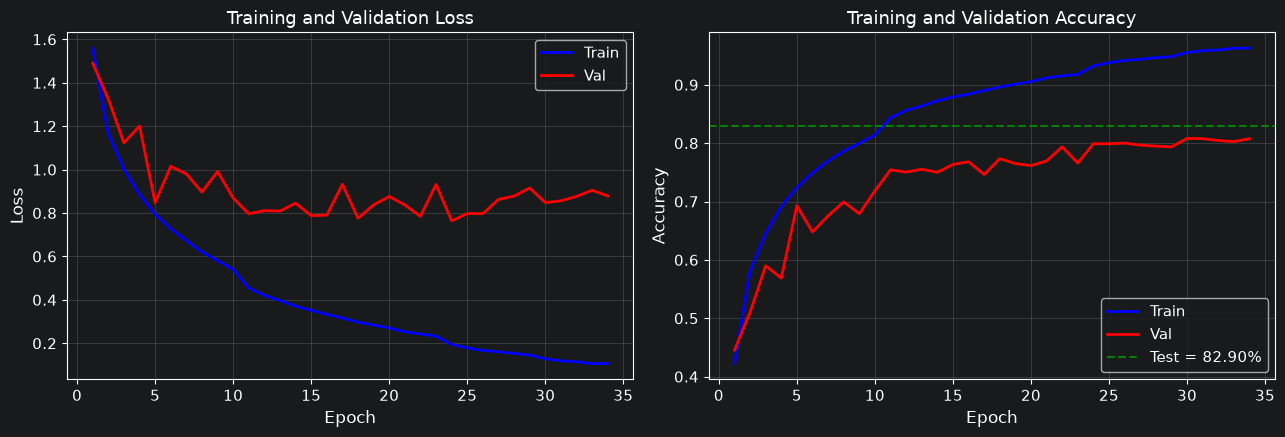

In [6]:
# Load training history
p1_history = load_json(os.path.join(PART1_DIR, 'baseline_history.json'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(p1_history['loss']) + 1)

axes[0].plot(epochs, p1_history['loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs, p1_history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss'); axes[0].legend()

axes[1].plot(epochs, p1_history['accuracy'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, p1_history['val_accuracy'], 'r-', label='Val', linewidth=2)
axes[1].axhline(y=p1_metrics['test_accuracy'], color='g', linestyle='--',
                label=f"Test = {p1_metrics['test_accuracy']*100:.2f}%")
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## Part 2: Cloud Optimizations

We benchmarked four cloud optimization strategies:
1. **Mixed precision** (float16)
2. **Model parallelism** (MirroredStrategy)
3. **Batch processing** (batch size tuning)
4. **Knowledge distillation** (teacher → student)

In [7]:
# Part 2: Cloud optimization results
p2 = load_json(os.path.join(PART2_DIR, 'cloud_optimization_results.json'))

print("=" * 60)
print("CLOUD OPTIMIZATION RESULTS")
print("=" * 60)

mp = p2['mixed_precision']
print(f"\nMixed Precision:")
print(f"  Speedup vs fp32:     {mp['speedup_vs_fp32']:.3f}×")
print(f"  Test accuracy:       {mp['test_accuracy']*100:.2f}%")
print(f"  Δ vs fp32:           {mp['accuracy_delta']*100:+.2f}%")

bp = p2['batch_processing']
print(f"\nBatch Processing (throughput):")
for bs in ['64', '128', '256', '512']:
    print(f"  Batch {bs}: {bp[bs]['throughput_samples_per_s']:.0f} samples/s, "
          f"acc={bp[bs]['test_accuracy']*100:.2f}%")

kd = p2['knowledge_distillation']
print(f"\nKnowledge Distillation:")
print(f"  Teacher params:      {kd['teacher_params']:,}")
print(f"  Student params:      {kd['student_params']:,}")
print(f"  Compression ratio:   {kd['compression_ratio']}×")
print(f"  Teacher accuracy:    {kd['teacher_test_accuracy']*100:.2f}%")
print(f"  Student accuracy:    {kd['student_test_accuracy']*100:.2f}%")

CLOUD OPTIMIZATION RESULTS

Mixed Precision:
  Speedup vs fp32:     1.100×
  Test accuracy:       79.32%
  Δ vs fp32:           -1.65%

Batch Processing (throughput):
  Batch 64: 2088 samples/s, acc=77.80%
  Batch 128: 2292 samples/s, acc=79.27%
  Batch 256: 2319 samples/s, acc=80.02%
  Batch 512: 2345 samples/s, acc=77.48%

Knowledge Distillation:
  Teacher params:      751,418
  Student params:      324,394
  Compression ratio:   2.32×
  Teacher accuracy:    77.04%
  Student accuracy:    77.10%


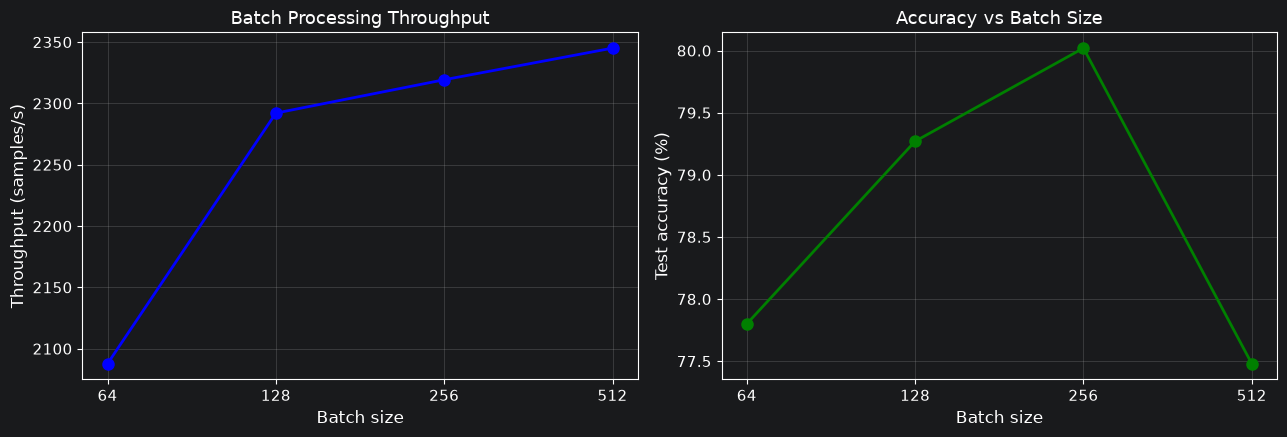

In [8]:
# Part 2: Batch processing visualization
batch_sizes = [64, 128, 256, 512]
throughput = [bp[str(b)]['throughput_samples_per_s'] for b in batch_sizes]
accuracy = [bp[str(b)]['test_accuracy'] * 100 for b in batch_sizes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(batch_sizes, throughput, 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Batch size'); axes[0].set_ylabel('Throughput (samples/s)')
axes[0].set_title('Batch Processing Throughput')
axes[0].set_xscale('log', base=2); axes[0].set_xticks(batch_sizes); axes[0].set_xticklabels(batch_sizes)

axes[1].plot(batch_sizes, accuracy, 'g-o', linewidth=2, markersize=8)
axes[1].set_xlabel('Batch size'); axes[1].set_ylabel('Test accuracy (%)')
axes[1].set_title('Accuracy vs Batch Size')
axes[1].set_xscale('log', base=2); axes[1].set_xticks(batch_sizes); axes[1].set_xticklabels(batch_sizes)

plt.tight_layout()
plt.show()

---
## Part 3: Edge Optimizations

We benchmarked four edge optimization strategies:
1. **Magnitude-based pruning** (50%, 75%, 90%)
2. **Post-training quantization** (dynamic range, float16, INT8)
3. **Architecture optimization** (depthwise separable convs)
4. **Simplified NAS**

In [9]:
# Part 3: Edge optimization results
p3 = load_json(os.path.join(PART3_DIR, 'edge_optimization_results.json'))

print("=" * 60)
print("EDGE OPTIMIZATION RESULTS")
print("=" * 60)

print(f"\nPruning:")
for key in ['sparsity_50', 'sparsity_75', 'sparsity_90']:
    s = p3['pruning'][key]
    print(f"  {key}: acc={s['test_accuracy']*100:.2f}%, "
          f"actual sparsity={s['actual_sparsity']*100:.1f}%, "
          f"non-zero params={s['non_zero_params']:,}")

print(f"\nQuantization:")
for method in ['dynamic_range', 'float16', 'int8']:
    q = p3['quantization'][method]
    print(f"  {method:15s}: size={q['size_kb']:.1f} KB, acc={q['accuracy']*100:.2f}%")

print(f"\nArchitecture Optimization:")
arch = p3['architecture']
print(f"  Params:              {arch['params']:,}")
print(f"  Compression:         {arch['compression_vs_baseline']}×")
print(f"  Accuracy:            {arch['test_accuracy']*100:.2f}%")

print(f"\nDeployment Viability:")
for platform, info in p3['deployment_viability'].items():
    status = "✅" if info['viable'] else "❌"
    print(f"  {status} {platform}")

EDGE OPTIMIZATION RESULTS

Pruning:
  sparsity_50: acc=83.75%, actual sparsity=49.6%, non-zero params=163,450
  sparsity_75: acc=81.74%, actual sparsity=74.4%, non-zero params=82,977
  sparsity_90: acc=66.56%, actual sparsity=89.3%, non-zero params=34,695

Quantization:
  dynamic_range  : size=336.3 KB, acc=83.15%
  float16        : size=642.5 KB, acc=83.20%
  int8           : size=343.2 KB, acc=82.95%

Architecture Optimization:
  Params:              35,501
  Compression:         9.14×
  Accuracy:            72.46%

Deployment Viability:
  ✅ raspberry_pi_4
  ✅ jetson_nano
  ✅ esp32
  ❌ arduino_nano_33_ble


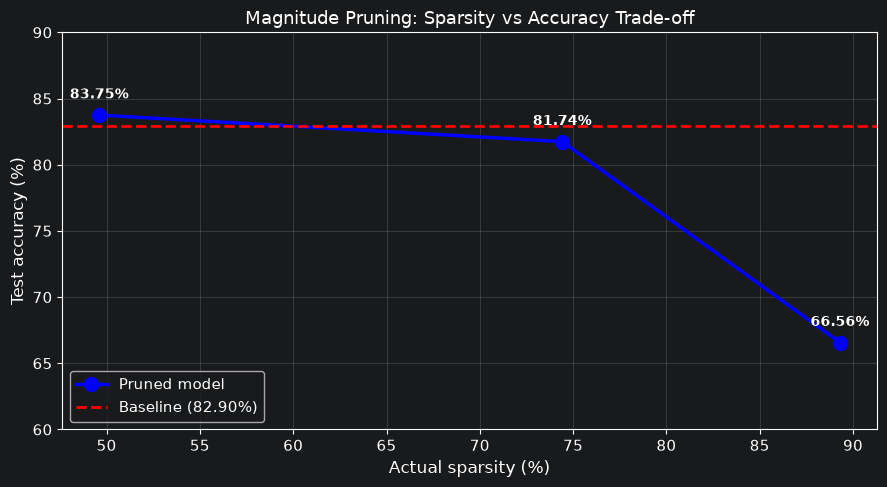

In [10]:
# Part 3: Pruning trade-off
sparsities = [p3['pruning'][f'sparsity_{s}']['actual_sparsity'] * 100 for s in [50, 75, 90]]
accuracies = [p3['pruning'][f'sparsity_{s}']['test_accuracy'] * 100 for s in [50, 75, 90]]

plt.figure(figsize=(9, 5))
plt.plot(sparsities, accuracies, 'b-o', linewidth=2.5, markersize=10, label='Pruned model')
plt.axhline(y=82.90, color='red', linestyle='--', linewidth=2, label='Baseline (82.90%)')
for x, y in zip(sparsities, accuracies):
    plt.annotate(f'{y:.2f}%', (x, y), textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=10, fontweight='bold')
plt.xlabel('Actual sparsity (%)'); plt.ylabel('Test accuracy (%)')
plt.title('Magnitude Pruning: Sparsity vs Accuracy Trade-off')
plt.legend(loc='lower left'); plt.ylim([60, 90])
plt.tight_layout(); plt.show()

---
## Part 4: Multi-Scale Deployment Pipeline

The pipeline automatically optimizes the same model for three deployment
targets, subject to their resource constraints.

In [11]:
# Part 4: Multi-scale results
p4 = load_json(os.path.join(PART4_DIR, 'multi_scale_optimization_report.json'))
results = p4['optimization_results']

print("=" * 70)
print(f"{'Target':<20} {'Accuracy':>10} {'Size (MB)':>12} {'Latency (ms)':>14} {'Strategy':>25}")
print("=" * 70)
for target, r in results.items():
    print(f"{target:<20} {r['accuracy']*100:>9.2f}% {r['model_size_mb']:>12.3f} "
          f"{r['estimated_latency_ms']:>14.3f} {r['optimization_strategy']:>25}")
print("=" * 70)

print("\nPareto-optimal models:")
for p in p4['scaling_analysis']['pareto_frontier']:
    print(f"  - {p['name']}: acc={p['accuracy']*100:.2f}%, size={p['size_mb']:.3f} MB")

Target                 Accuracy    Size (MB)   Latency (ms)                  Strategy
cloud_server             83.20%        0.627          0.890      float16 quantization
edge_device              82.35%        0.328          0.226 pruning(50%) + dynamic_range_quant
microcontroller          61.60%        0.018          0.028     tiny_arch + full_INT8

Pareto-optimal models:
  - cloud_server: acc=83.20%, size=0.627 MB
  - edge_device: acc=82.35%, size=0.328 MB
  - microcontroller: acc=61.60%, size=0.018 MB


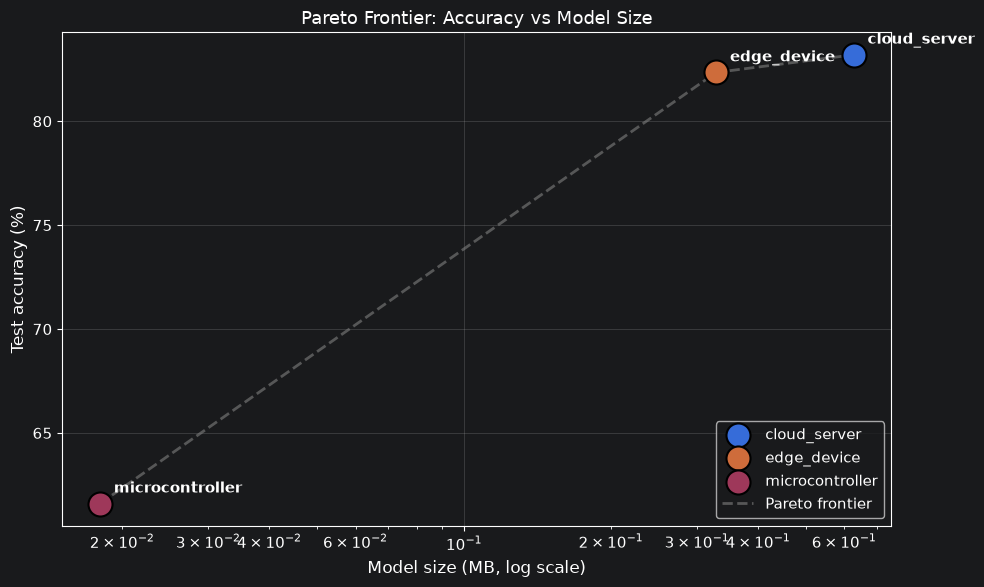

In [12]:
# Part 4: Pareto frontier
fig, ax = plt.subplots(figsize=(10, 6))
for target, r in results.items():
    ax.scatter(r['model_size_mb'], r['accuracy'] * 100,
               s=300, label=target, zorder=5,
               edgecolors='black', linewidth=1.5)
    ax.annotate(target, (r['model_size_mb'], r['accuracy'] * 100),
                textcoords='offset points', xytext=(10, 8),
                fontsize=11, fontweight='bold')

sizes = [r['model_size_mb'] for r in results.values()]
accs = [r['accuracy'] * 100 for r in results.values()]
sorted_pairs = sorted(zip(sizes, accs))
pareto_sizes, pareto_accs = zip(*sorted_pairs)
ax.plot(pareto_sizes, pareto_accs, 'gray', linestyle='--',
        linewidth=2, alpha=0.6, label='Pareto frontier')

ax.set_xscale('log')
ax.set_xlabel('Model size (MB, log scale)')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Pareto Frontier: Accuracy vs Model Size')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

---
## TFLite Inference Demo

Let's load one of the deployed TFLite models and run a prediction on a
sample image from the CIFAR-10 test set.

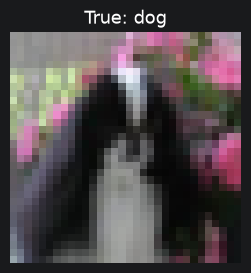

Model: model_int8.tflite
True label:       dog
Predicted label:  dog
Confidence:       23.12%
Correct:          ✅


/Users/ivan/PycharmProjects/mls-assignment2/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [13]:
import tensorflow as tf
import pickle

# Load one sample from CIFAR-10 test set
cache_dir = os.path.expanduser('~/.keras/datasets/cifar-10-batches-py')

with open(os.path.join(cache_dir, 'test_batch'), 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

x_test = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_test = np.array(batch[b'labels'])

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Pick a sample
idx = 42
sample = x_test[idx:idx+1].astype('float32') / 255.0
true_label = y_test[idx]

# Display the image
plt.figure(figsize=(3, 3))
plt.imshow(sample[0])
plt.title(f"True: {class_names[true_label]}")
plt.axis('off')
plt.show()

# Load and run TFLite model
tflite_path = os.path.join(PART3_DIR, 'edge_optimized_models', 'model_int8.tflite')
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

inp = interpreter.get_input_details()
out = interpreter.get_output_details()

x = sample
if inp[0]['dtype'] == np.int8:
    scale, zp = inp[0]['quantization']
    x = (x / scale + zp).astype(np.int8)

interpreter.set_tensor(inp[0]['index'], x)
interpreter.invoke()
pred = interpreter.get_tensor(out[0]['index'])

if pred.dtype == np.int8:
    scale, zp = out[0]['quantization']
    pred = (pred.astype(np.float32) - zp) * scale

predicted_class = int(np.argmax(pred))
confidence = float(np.max(tf.nn.softmax(pred[0])))

print(f"Model: {os.path.basename(tflite_path)}")
print(f"True label:       {class_names[true_label]}")
print(f"Predicted label:  {class_names[predicted_class]}")
print(f"Confidence:       {confidence*100:.2f}%")
print(f"Correct:          {'✅' if predicted_class == true_label else '❌'}")

---
## Summary

This notebook demonstrated the key results of the multi-scale optimization
pipeline. The baseline CNN (324k params, 82.90% accuracy) was successfully
optimized for three deployment targets:

| Target | Accuracy | Size | Key Technique |
|--------|----------|------|---------------|
| Cloud  | 83.20%   | 0.627 MB | float16 quantization |
| Edge   | 82.35%   | 0.328 MB | pruning(50%) + dynamic range |
| Micro  | 61.60%   | 0.018 MB | tiny arch + INT8 |

**Key findings:**
- Pruning at 50% *improves* accuracy (+0.85%) due to regularization
- Quantization preserves accuracy while reducing size by 3.7×
- The full multi-scale pipeline compresses the model by 35× while preserving
  the accuracy until the microcontroller tier

For detailed analysis, see `multi_scale_analysis.pdf`.